
# Sports Betting Fraud Detection

**Group Members:** Aryaman Arora (aa833), Hyunjin Lee (hl494), Suhaib Mansour (sm1097), Emily Zhao (egz5)



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import difflib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Load data

In [2]:
odds_df = pd.read_csv("matches_odds.csv")
results_df = pd.read_csv("matches_results.csv")

print("Odds data:", odds_df.shape)
print("Results data:", results_df.shape)

print(odds_df.columns.tolist())
print(odds_df.head(3))   #show first 3 rows of odds dataset

print(results_df.columns.tolist())
print(results_df.head(3))   #show first 3 rows of results datset

Odds data: (461144, 9)
Results data: (32508, 8)
['match_id', 'date_start', 'competition_name', 'date_created', 'home_team_name', 'away_team_name', 'home_team_odd', 'away_team_odd', 'tie_odd']
   match_id        date_start     competition_name      date_created  \
0         1  12/26/2016 12:30  Eng. Premier League  12/26/2016 12:00   
1         1  12/26/2016 12:30  Eng. Premier League   12/26/2016 6:45   
2         1  12/26/2016 12:30  Eng. Premier League   12/26/2016 3:35   

  home_team_name  away_team_name  home_team_odd  away_team_odd  tie_odd  
0        Watford  Crystal Palace           2.35            3.1     3.10  
1        Watford  Crystal Palace           2.40            3.0     3.25  
2        Watford  Crystal Palace           2.40            3.1     3.10  
['match_id', 'date_start', 'competition_name', 'home_team_name', 'away_team_name', 'home_team_score', 'away_team_score', 'final_result']
   match_id        date_start     competition_name     home_team_name  \
0         1  

In [3]:
#standardize dataset column names

odds_df = odds_df.rename(columns={
    "date_start": "Date",
    "home_team_name": "HomeTeam",
    "away_team_name": "AwayTeam",
    "home_team_odd": "HomeOdds",
    "away_team_odd": "AwayOdds",
    "tie_odd": "DrawOdds"
})


results_df = results_df.rename(columns={
    "date_start": "Date",
    "home_team_name": "HomeTeam",
    "away_team_name": "AwayTeam",
    "home_team_score": "HomeGoals",
    "away_team_score": "AwayGoals"
})

odds_df["Date"] = pd.to_datetime(odds_df["Date"], errors="coerce")
results_df["Date"] = pd.to_datetime(results_df["Date"], errors="coerce")

odds_df = odds_df.sort_values("Date").drop_duplicates(
    subset=["HomeTeam", "AwayTeam", "Date"], keep="last"
)

In [4]:
#merge dataset

merged = pd.merge(
    results_df,
    odds_df[["Date", "HomeTeam", "AwayTeam", "HomeOdds", "AwayOdds", "DrawOdds"]],
    on=["Date", "HomeTeam", "AwayTeam"],
    how="inner"
)

print("\nMerged shape:", merged.shape)
print(merged.head(3))

merged["delta_home_away"] = merged["HomeOdds"] - merged["AwayOdds"]
merged["avg_odds"] = merged[["HomeOdds", "AwayOdds", "DrawOdds"]].mean(axis=1)
merged["odds_volatility"] = merged[["HomeOdds", "AwayOdds", "DrawOdds"]].std(axis=1)




Merged shape: (32508, 11)
   match_id                Date     competition_name           HomeTeam  \
0         1 2016-12-26 12:30:00  Eng. Premier League            Watford   
1         2 2016-12-26 15:00:00  Eng. Premier League            Burnley   
2         3 2016-12-26 15:00:00  Eng. Premier League  Manchester United   

         AwayTeam  HomeGoals  AwayGoals final_result  HomeOdds  AwayOdds  \
0  Crystal Palace          1          1            x      2.45       3.1   
1   Middlesbrough          1          0            1      3.00       2.6   
2      Sunderland          3          1            1      1.18      14.5   

   DrawOdds  
0       3.1  
1       3.0  
2       6.5  


In [5]:
def match_result(row):
    if row["HomeGoals"] > row["AwayGoals"]:
        return "H"
    elif row["HomeGoals"] < row["AwayGoals"]:
        return "A"
    else:
        return "D"
    
merged["MatchResult"] = merged.apply(match_result, axis=1)

## Clean data


In [6]:
def standardize_team_names(df, col, canonical_names, cutoff=0.7):
    def match_name(name):
        matches = difflib.get_close_matches(str(name), canonical_names, n=1, cutoff=cutoff)
        return matches[0] if matches else name
    df[col] = df[col].apply(match_name)
    return df

def clean_betting_data(match_df, odds_df):
    match_df["Date"] = pd.to_datetime(match_df["Date"], errors="coerce")
    odds_df["Date"] = pd.to_datetime(odds_df["Date"], errors="coerce")

    match_df = match_df.dropna(subset=["HomeTeam", "AwayTeam"])
    match_df = match_df.drop_duplicates(subset=["HomeTeam", "AwayTeam", "Date"])

    merged = pd.merge(match_df, odds_df, on=["Date", "HomeTeam", "AwayTeam"], how="inner")

    # Adapted to your columns (home_team_odd, away_team_odd, tie_odd)
    merged["delta_odds"] = merged["HomeOdds"] - merged["AwayOdds"]
    merged["odds_volatility"] = merged[["HomeOdds", "AwayOdds", "DrawOdds"]].std(axis=1)
    merged["odds_pct_change"] = (merged["delta_odds"] / merged["HomeOdds"]).fillna(0)

    numeric_cols = ["delta_odds", "odds_volatility", "odds_pct_change"]
    merged[numeric_cols] = merged[numeric_cols].fillna(merged[numeric_cols].median())

    return merged

def add_features_and_labels(df):
    scaler = MinMaxScaler()
    features = ["delta_odds", "odds_volatility", "odds_pct_change"]
    df[[f + "_scaled" for f in features]] = scaler.fit_transform(df[features])
    threshold = df["delta_odds"].abs().quantile(0.95)
    df["suspicious"] = (df["delta_odds"].abs() >= threshold).astype(int)
    return df

def plot_distributions(df):
    plt.figure(figsize=(8, 5))
    sns.histplot(df["delta_odds"], bins=30, kde=True)
    plt.title("Distribution of Odds Change (ΔOdds)")
    plt.xlabel("ΔOdds")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(x="suspicious", y="odds_volatility", data=df)
    plt.title("Volatility by Suspicious Label")
    plt.show()

## Descriptive statistics table

In [7]:
numeric_features = ["HomeOdds", "AwayOdds", "DrawOdds", "delta_home_away", "odds_volatility"]

desc_stats = merged[numeric_features].describe().T  # transpose for readability
desc_stats = desc_stats[["mean", "std", "min", "max"]].round(2)
desc_stats = desc_stats.rename(
    columns={
        "mean": "Mean",
        "std": "Std Dev",
        "min": "Min",
        "max": "Max"
    }
)

# Display as a labeled table
print("Table 1. Descriptive Statistics of Key Betting Features")
display(desc_stats)


Table 1. Descriptive Statistics of Key Betting Features


,Mean,Std Dev,Min,Max
HomeOdds,2.61,2.18,1.01,90.00
AwayOdds,3.84,2.94,1.01,55.00
DrawOdds,3.59,1.00,0.00,21.00
delta_home_away,-1.23,4.15,-53.99,64.00
odds_volatility,1.39,1.76,0.00,46.32


## Data visualization/plots

In [8]:
merged.to_csv("Merged_Matches_Odds_Results.csv", index=False)
print("\nSaved as Merged_Matches_Odds_Results.csv")
#save cleaned dataset


Saved as Merged_Matches_Odds_Results.csv


## Random Forest Classifier

In [9]:
df = pd.read_csv("Merged_Matches_Odds_Results.csv")
df["delta_odds"] = df["HomeOdds"] - df["AwayOdds"]
df["odds_volatility"] = df[["HomeOdds","AwayOdds","DrawOdds"]].std(axis=1)
df["odds_pct_change"] = (df["delta_odds"]/df["HomeOdds"]).fillna(0)
df["suspicious"] = (df["delta_odds"].abs() >= df["delta_odds"].abs().quantile(0.95)).astype(int)

X = df[["delta_odds","odds_volatility","odds_pct_change"]]
y = df["suspicious"]
X = MinMaxScaler().fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

rf = RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced').fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test,y_pred,digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      6177
           1     1.0000    1.0000    1.0000       325

    accuracy                         1.0000      6502
   macro avg     1.0000    1.0000    1.0000      6502
weighted avg     1.0000    1.0000    1.0000      6502



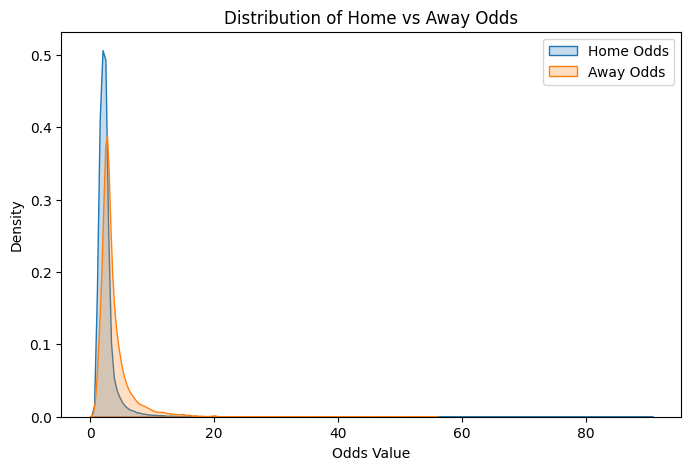

In [10]:
plt.figure(figsize=(8,5))
sns.kdeplot(x=merged["HomeOdds"], label="Home Odds", fill=True)
sns.kdeplot(x=merged["AwayOdds"], label="Away Odds", fill=True)
plt.title("Distribution of Home vs Away Odds")
plt.xlabel("Odds Value")
plt.ylabel("Density")
plt.legend()
plt.show()


C:\Users\metal\AppData\Local\Temp\ipykernel_12872\4005724700.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = merged.groupby("odds_bin")["home_win"].mean().reset_index()


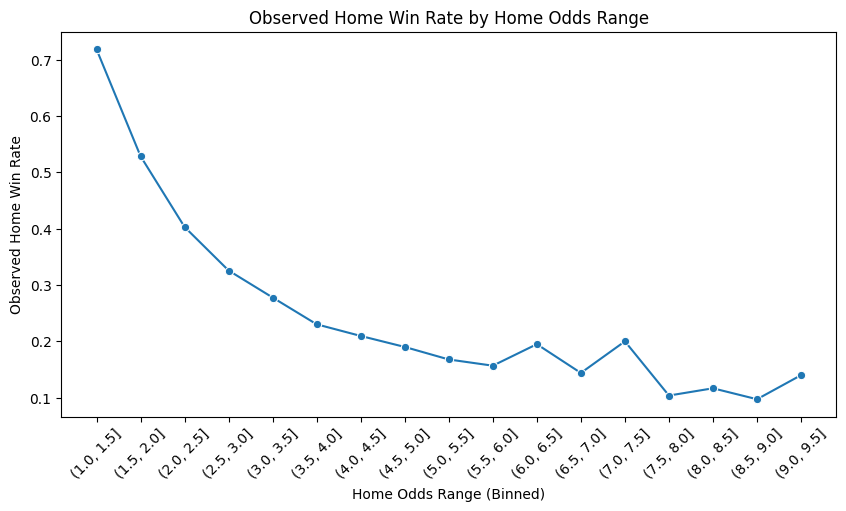

In [11]:
merged["home_win"] = (merged["HomeGoals"] > merged["AwayGoals"]).astype(int)
merged["odds_bin"] = pd.cut(merged["HomeOdds"], bins=np.arange(1, 10, 0.5))

win_rate = merged.groupby("odds_bin")["home_win"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=win_rate.index, y="home_win", data=win_rate, marker="o")
plt.title("Observed Home Win Rate by Home Odds Range")
plt.xlabel("Home Odds Range (Binned)")
plt.ylabel("Observed Home Win Rate")
plt.xticks(win_rate.index, win_rate["odds_bin"], rotation=45)
plt.show()


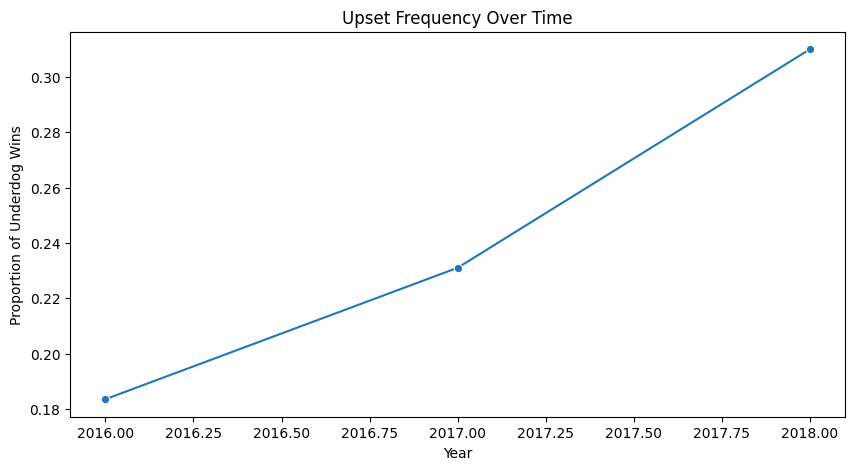

In [12]:
merged["Year"] = merged["Date"].dt.year
merged["underdog_win"] = ((merged["HomeOdds"] > merged["AwayOdds"]) & (merged["HomeGoals"] > merged["AwayGoals"])) | \
                         ((merged["AwayOdds"] > merged["HomeOdds"]) & (merged["AwayGoals"] > merged["HomeGoals"]))
upset_rate = merged.groupby("Year")["underdog_win"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="Year", y="underdog_win", data=upset_rate, marker="o")
plt.title("Upset Frequency Over Time")
plt.ylabel("Proportion of Underdog Wins")
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
import numpy as np

# --- Data Loading and Feature Calculation  ---
df = pd.read_csv("Merged_Matches_Odds_Results.csv")
df["delta_odds"] = df["HomeOdds"] - df["AwayOdds"]
df["odds_volatility"] = df[["HomeOdds","AwayOdds","DrawOdds"]].std(axis=1)
df["odds_pct_change"] = (df["delta_odds"]/df["HomeOdds"]).fillna(0)

# ----------------- Unsupervised Learning Implementation -----------------

# 1. Define the Feature Matrix (X)
# We use the same features calculated in your original notebook
X = df[["delta_odds", "odds_volatility", "odds_pct_change"]]

# 2. Scale the Features (Important for distance-based models)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Initialize the Isolation Forest Model
# The 'contamination' parameter estimates the proportion of outliers in the data.
# We set it to 0.05 (5%), similar to your original 0.95 quantile threshold.
# This guides the model in setting the decision boundary.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# 4. Fit the Model (No need for train/test split in this pure unsupervised approach)
iso_forest.fit(X_scaled)

# 5. Generate Predictions and Anomaly Scores
# 'raw_scores' are the decision function values: lower is more anomalous (higher suspicion)
raw_scores = iso_forest.decision_function(X_scaled)

# 'predictions' assigns a binary label: -1 for anomaly, 1 for normal
predictions = iso_forest.predict(X_scaled)

# 6. Add Results Back to DataFrame
df['anomaly_score'] = raw_scores
df['is_outlier'] = predictions

# Display the matches flagged as most anomalous
# The most suspicious matches will have the lowest (most negative) scores
suspicious_matches = df[df['is_outlier'] == -1].sort_values(
    'anomaly_score', 
    ascending=True
)

# Show the top 5 most suspicious matches
print(suspicious_matches.head())

       match_id                 Date        competition_name  \
20979    665755  2017-05-06 17:00:00  Russian Premier League   
24416    688837  2017-08-08 11:00:00     Aus. NPL Queensland   
13698    669121  2017-05-13 14:00:00       Italian Primavera   
14736    666823  2017-05-09 11:29:00       AFC Champs League   
21816    664643  2017-04-28 17:00:00   Estonian Meistriliiga   

                  HomeTeam             AwayTeam  HomeGoals  AwayGoals  \
20979       Spartak Moscow            Tom Tomsk          1          0   
24416     Moreton Bay Jets  Sunshine Coast Fire          7          1   
13698         Atalanta U19      Salernitana U19          7          0   
14736    Kawasaki Frontale     Eastern Athletic          4          0   
21816  Tallinna FC Levadia  Parnu Linnameeskond          8          0   

      final_result  HomeOdds  AwayOdds  DrawOdds  delta_home_away   avg_odds  \
20979            1      1.02      50.0      14.0           -48.98  21.673333   
24416           